# EDA Step 2: 타겟 클래스 불균형 분석 (Class Imbalance)

**목표**: 생존/사망 비율의 불균형이 모델 성능(F1 Score)에 미치는 영향을 분석합니다.

**분석 항목**:
- 전체 생존율 시각화
- 그룹별 생존율 비교 (sex, pclass, embarked, who, adult_male, alone)
- DummyClassifier 기반 F1 baseline 측정
- 현재 모델 Confusion Matrix 분석 (FN 집중)
- F1-Recall 시뮬레이션

> ⚠️ 핵심 인사이트: 현재 Recall=0.62 → 생존자 38%를 놓치고 있음. Recall 개선이 F1 향상의 1순위

In [1]:
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# SEED 고정 (절대 변경 금지)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.unicode_minus'] = False

print('Setup complete!')

Setup complete!


In [2]:
df = sns.load_dataset('titanic')
print(f'Data loaded: {df.shape[0]} rows x {df.shape[1]} columns')

Data loaded: 891 rows x 15 columns


## 2.1 전체 생존율 시각화

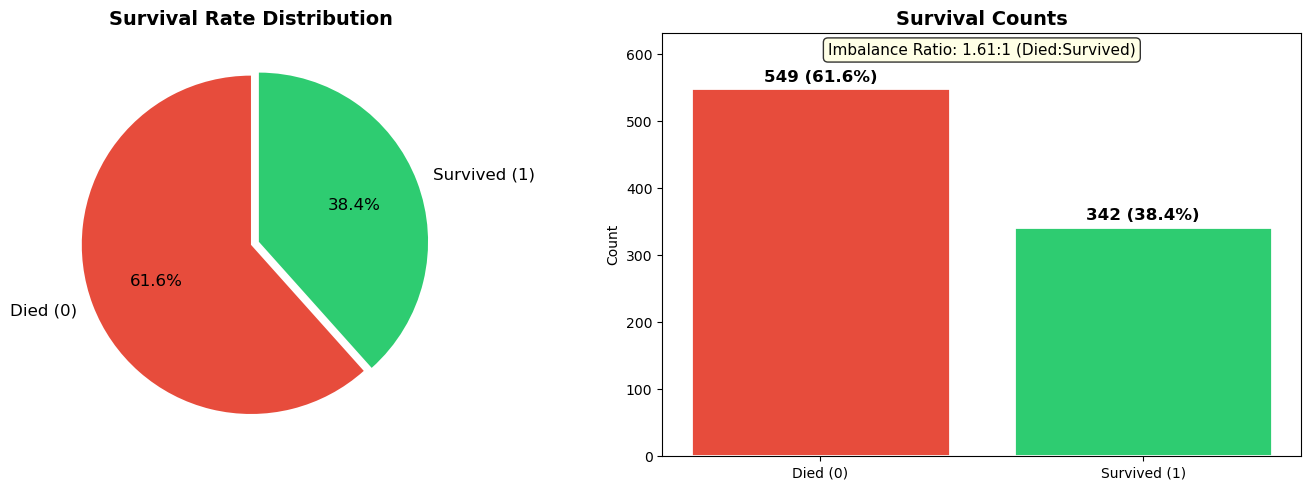


Survival Rate: 38.4%
Died: 549 (61.6%)
Survived: 342 (38.4%)
Imbalance Ratio: 1.61:1


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 파이 차트
survived_counts = df['survived'].value_counts()
labels = ['Died (0)', 'Survived (1)']
colors = ['#e74c3c', '#2ecc71']
explode = (0, 0.05)

axes[0].pie(survived_counts, labels=labels, autopct='%1.1f%%', colors=colors,
            explode=explode, startangle=90, textprops={'fontsize': 12})
axes[0].set_title('Survival Rate Distribution', fontsize=14, fontweight='bold')

# 바 차트
bars = axes[1].bar(labels, survived_counts.values, color=colors, edgecolor='white', linewidth=2)
for bar, val in zip(bars, survived_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{val} ({val/len(df)*100:.1f}%)', ha='center', fontsize=12, fontweight='bold')
axes[1].set_title('Survival Counts', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].set_ylim(0, max(survived_counts.values) * 1.15)

# 불균형 비율 표시
ratio = survived_counts[0] / survived_counts[1]
axes[1].text(0.5, 0.95, f'Imbalance Ratio: {ratio:.2f}:1 (Died:Survived)',
             transform=axes[1].transAxes, ha='center', fontsize=11,
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig('../reports/eda_step2_survival_rate.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nSurvival Rate: {df["survived"].mean()*100:.1f}%')
print(f'Died: {survived_counts[0]} ({survived_counts[0]/len(df)*100:.1f}%)')
print(f'Survived: {survived_counts[1]} ({survived_counts[1]/len(df)*100:.1f}%)')
print(f'Imbalance Ratio: {ratio:.2f}:1')

## 2.2 그룹별 생존율

In [4]:
# 그룹별 생존율 계산
group_vars = ['sex', 'pclass', 'embarked', 'who', 'adult_male', 'alone']

print('=' * 70)
print('GROUP-LEVEL SURVIVAL RATES')
print('=' * 70)

for var in group_vars:
    stats = df.groupby(var)['survived'].agg(['mean', 'count', 'sum']).round(3)
    stats.columns = ['Survival Rate', 'Total', 'Survived']
    stats['Died'] = stats['Total'] - stats['Survived']
    print(f'\n--- {var} ---')
    print(stats.to_string())

GROUP-LEVEL SURVIVAL RATES

--- sex ---
        Survival Rate  Total  Survived  Died
sex                                         
female          0.742    314       233    81
male            0.189    577       109   468

--- pclass ---
        Survival Rate  Total  Survived  Died
pclass                                      
1               0.630    216       136    80
2               0.473    184        87    97
3               0.242    491       119   372

--- embarked ---
          Survival Rate  Total  Survived  Died
embarked                                      
C                 0.554    168        93    75
Q                 0.390     77        30    47
S                 0.337    644       217   427

--- who ---
       Survival Rate  Total  Survived  Died
who                                        
child          0.590     83        49    34
man            0.164    537        88   449
woman          0.756    271       205    66

--- adult_male ---
            Survival Rate  Total 

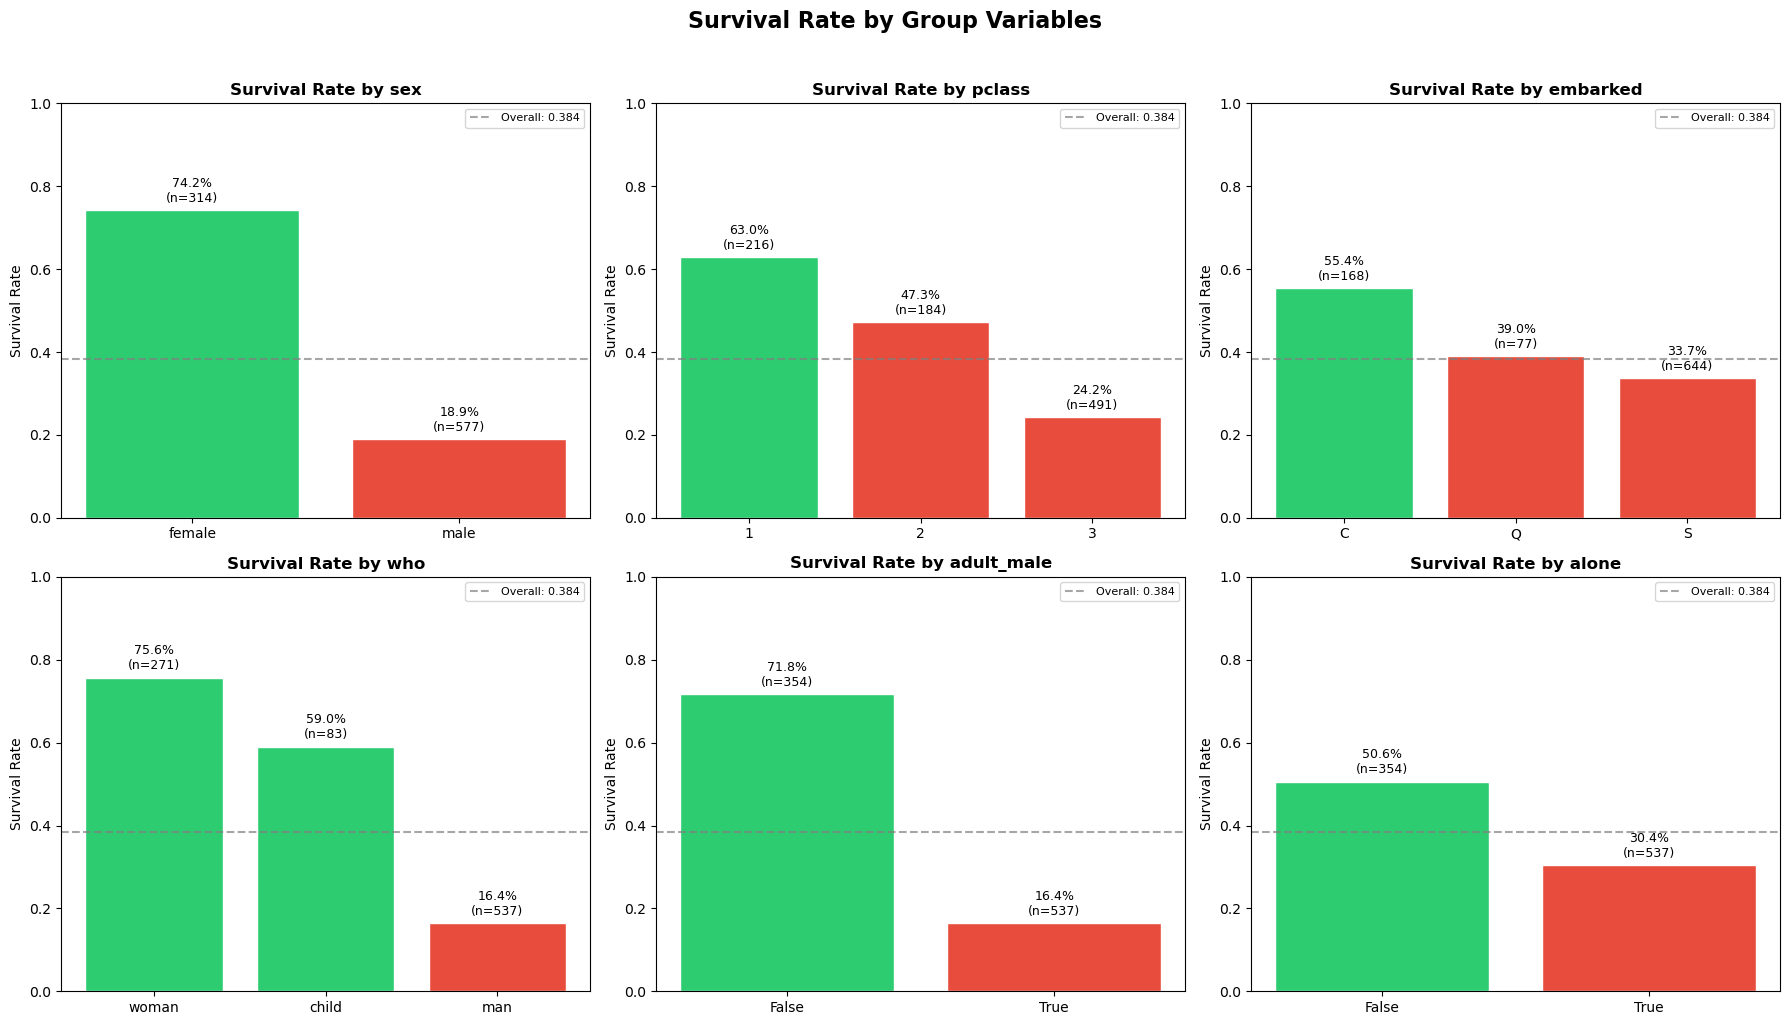

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, var in enumerate(group_vars):
    ax = axes[idx]
    survival_rates = df.groupby(var)['survived'].mean().sort_values(ascending=False)
    counts = df.groupby(var)['survived'].count()
    
    colors_bar = ['#2ecc71' if r > 0.5 else '#e74c3c' for r in survival_rates]
    bars = ax.bar(range(len(survival_rates)), survival_rates.values, color=colors_bar, edgecolor='white')
    
    ax.set_xticks(range(len(survival_rates)))
    ax.set_xticklabels([str(x) for x in survival_rates.index], fontsize=10)
    ax.set_title(f'Survival Rate by {var}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Survival Rate')
    ax.set_ylim(0, 1.0)
    ax.axhline(y=df['survived'].mean(), color='gray', linestyle='--', alpha=0.7, label=f'Overall: {df["survived"].mean():.3f}')
    
    for bar, rate, idx_name in zip(bars, survival_rates.values, survival_rates.index):
        n = counts[idx_name]
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{rate:.1%}\n(n={n})', ha='center', fontsize=9)
    ax.legend(fontsize=8)

plt.suptitle('Survival Rate by Group Variables', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/eda_step2_survival_by_group.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.3 클래스 불균형이 F1에 미치는 영향

In [6]:
# DummyClassifier 비교: 불균형 데이터에서 기대할 수 있는 최소 성능
# 피처 준비 (간단한 수치형만 사용)
X_dummy = df[['pclass', 'age', 'sibsp', 'parch', 'fare']].copy()
X_dummy['age'] = X_dummy['age'].fillna(X_dummy['age'].median())
y = df['survived']

strategies = ['most_frequent', 'stratified', 'uniform']
strategy_names = ['Most Frequent (All Died)', 'Stratified (Random by ratio)', 'Uniform (Random 50/50)']
results = []

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

for strategy, name in zip(strategies, strategy_names):
    f1_scores = []
    prec_scores = []
    rec_scores = []
    
    for train_idx, val_idx in skf.split(X_dummy, y):
        clf = DummyClassifier(strategy=strategy, random_state=SEED)
        clf.fit(X_dummy.iloc[train_idx], y.iloc[train_idx])
        y_pred = clf.predict(X_dummy.iloc[val_idx])
        
        f1_scores.append(f1_score(y.iloc[val_idx], y_pred, zero_division=0))
        prec_scores.append(precision_score(y.iloc[val_idx], y_pred, zero_division=0))
        rec_scores.append(recall_score(y.iloc[val_idx], y_pred, zero_division=0))
    
    results.append({
        'Strategy': name,
        'F1 (mean)': np.mean(f1_scores),
        'Precision (mean)': np.mean(prec_scores),
        'Recall (mean)': np.mean(rec_scores),
        'F1 (std)': np.std(f1_scores)
    })

dummy_df = pd.DataFrame(results)
print('DummyClassifier Baseline Comparison (5-Fold CV)')
print('=' * 70)
print(dummy_df.to_string(index=False, float_format='{:.4f}'.format))
print()
print('=> Most Frequent: F1=0 (모두 사망으로 예측 -> TP=0)')
print('=> Stratified: 데이터 비율 기반 랜덤 예측')
print('=> Uniform: 50/50 랜덤 예측')

DummyClassifier Baseline Comparison (5-Fold CV)
                    Strategy  F1 (mean)  Precision (mean)  Recall (mean)  F1 (std)
    Most Frequent (All Died)     0.0000            0.0000         0.0000    0.0000
Stratified (Random by ratio)     0.3429            0.3602         0.3272    0.0592
      Uniform (Random 50/50)     0.4260            0.3681         0.5057    0.0371

=> Most Frequent: F1=0 (모두 사망으로 예측 -> TP=0)
=> Stratified: 데이터 비율 기반 랜덤 예측
=> Uniform: 50/50 랜덤 예측


## 2.4 Baseline Confusion Matrix 분석

In [7]:
# Baseline RandomForest 재현 (config.yaml 기준)
features = ['pclass', 'age', 'sibsp', 'parch', 'fare']
cat_features = ['sex', 'embarked', 'alone']

X = df[features + cat_features].copy()
X['age'] = X['age'].fillna(X.groupby(['pclass'])['age'].transform('median'))
X['embarked'] = X['embarked'].fillna('S')

le_dict = {}
for col in cat_features:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    le_dict[col] = le

y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=SEED, stratify=y
)

rf = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=SEED)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print('Baseline Model: RandomForest (n_estimators=200, max_depth=5)')
print('=' * 50)
print(classification_report(y_test, y_pred, target_names=['Died', 'Survived']))

f1 = f1_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
print(f'\nF1 Score: {f1:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Recall: {rec:.4f}')

Baseline Model: RandomForest (n_estimators=200, max_depth=5)
              precision    recall  f1-score   support

        Died       0.79      0.90      0.84       165
    Survived       0.79      0.61      0.69       103

    accuracy                           0.79       268
   macro avg       0.79      0.75      0.76       268
weighted avg       0.79      0.79      0.78       268


F1 Score: 0.6885
Precision: 0.7875
Recall: 0.6117


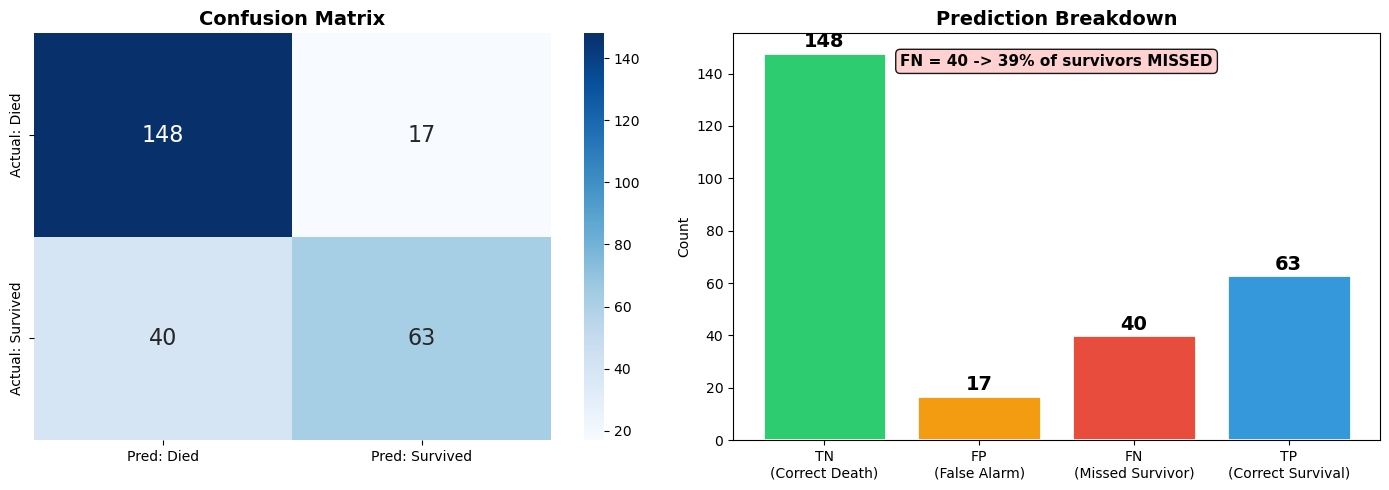


=== FN Analysis ===
False Negatives (missed survivors): 40
Percentage of survivors missed: 38.8%
=> Recall 개선이 F1 향상의 핵심 전략


In [8]:
# Confusion Matrix 시각화
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Pred: Died', 'Pred: Survived'],
            yticklabels=['Actual: Died', 'Actual: Survived'],
            annot_kws={'size': 16})
axes[0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')

# FN 하이라이트 - 놓친 생존자 분석
labels_cm = ['TN\n(Correct Death)', 'FP\n(False Alarm)', 'FN\n(Missed Survivor)', 'TP\n(Correct Survival)']
values = [tn, fp, fn, tp]
colors_cm = ['#2ecc71', '#f39c12', '#e74c3c', '#3498db']

bars = axes[1].bar(labels_cm, values, color=colors_cm, edgecolor='white', linewidth=2)
for bar, val in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 str(val), ha='center', fontsize=14, fontweight='bold')

axes[1].set_title('Prediction Breakdown', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count')

# FN 강조 박스
fn_pct = fn / (fn + tp) * 100
axes[1].text(0.5, 0.92, f'FN = {fn} -> {fn_pct:.0f}% of survivors MISSED',
             transform=axes[1].transAxes, ha='center', fontsize=11,
             bbox=dict(boxstyle='round', facecolor='#ffcccc', alpha=0.9), fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/eda_step2_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n=== FN Analysis ===')
print(f'False Negatives (missed survivors): {fn}')
print(f'Percentage of survivors missed: {fn_pct:.1f}%')
print(f'=> Recall 개선이 F1 향상의 핵심 전략')

## 2.5 F1-Recall 시뮬레이션

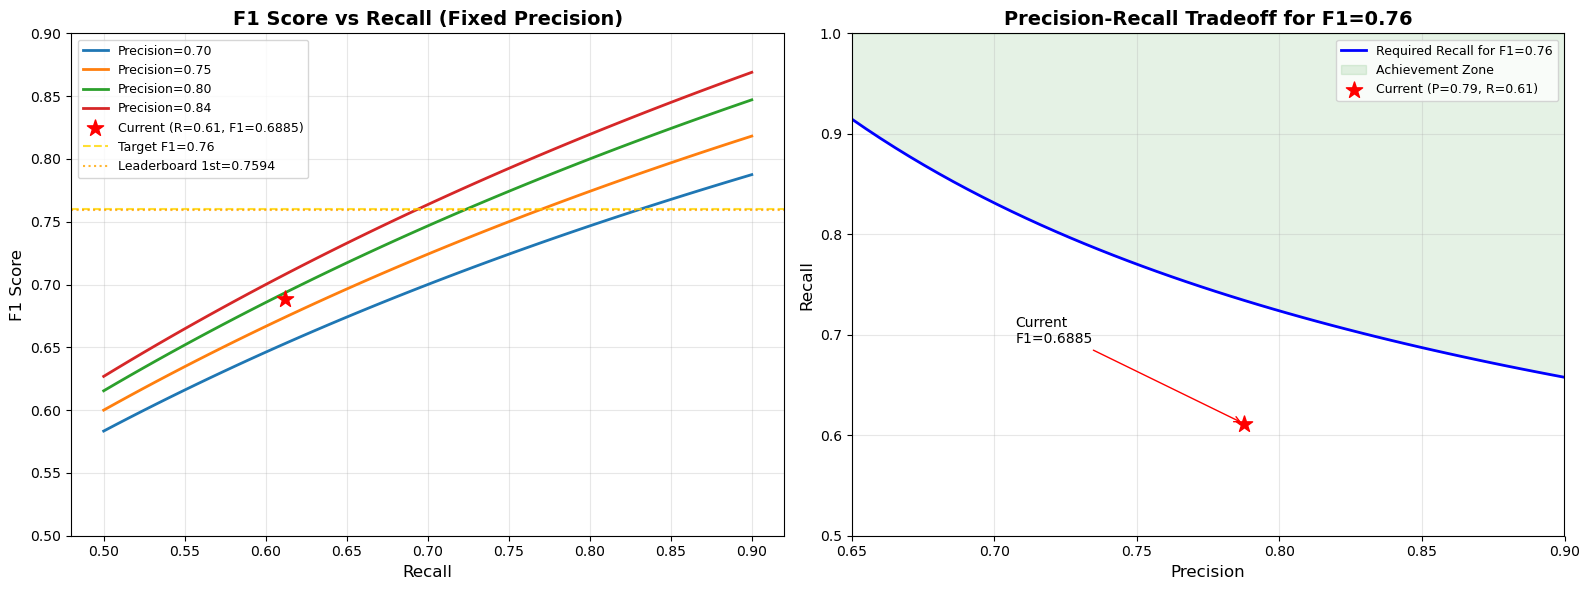


=== F1 = 0.76 Achievement Scenarios ===
  Precision=0.80 -> Recall needed: 0.7238
  Precision=0.84 -> Recall needed: 0.6939
  Precision=0.75 -> Recall needed: 0.7703


In [9]:
# Precision을 고정하고 Recall 변화에 따른 F1 시뮬레이션
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 시뮬레이션 1: Precision 고정, Recall 변화
precisions = [0.70, 0.75, 0.80, 0.84]
recalls = np.linspace(0.50, 0.90, 50)

for p in precisions:
    f1_vals = 2 * p * recalls / (p + recalls)
    axes[0].plot(recalls, f1_vals, label=f'Precision={p:.2f}', linewidth=2)

# 현재 위치 표시
current_f1 = 2 * prec * rec / (prec + rec)
axes[0].scatter([rec], [current_f1], color='red', s=150, zorder=5, marker='*', label=f'Current (R={rec:.2f}, F1={current_f1:.4f})')

# 목표 F1 라인
axes[0].axhline(y=0.76, color='gold', linestyle='--', alpha=0.8, label='Target F1=0.76')
axes[0].axhline(y=0.7594, color='orange', linestyle=':', alpha=0.8, label='Leaderboard 1st=0.7594')

axes[0].set_xlabel('Recall', fontsize=12)
axes[0].set_ylabel('F1 Score', fontsize=12)
axes[0].set_title('F1 Score vs Recall (Fixed Precision)', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0.5, 0.9)

# 시뮬레이션 2: 목표 F1=0.76 달성 시나리오
target_f1 = 0.76
prec_range = np.linspace(0.65, 0.90, 50)
rec_needed = target_f1 * prec_range / (2 * prec_range - target_f1)

# 유효한 범위만 필터
valid = (rec_needed > 0) & (rec_needed <= 1)
axes[1].plot(prec_range[valid], rec_needed[valid], 'b-', linewidth=2, label='Required Recall for F1=0.76')
axes[1].fill_between(prec_range[valid], rec_needed[valid], 1.0, alpha=0.1, color='green', label='Achievement Zone')

# 현재 위치
axes[1].scatter([prec], [rec], color='red', s=150, zorder=5, marker='*', label=f'Current (P={prec:.2f}, R={rec:.2f})')
axes[1].annotate(f'Current\nF1={current_f1:.4f}', xy=(prec, rec), xytext=(prec-0.08, rec+0.08),
                 fontsize=10, arrowprops=dict(arrowstyle='->', color='red'))

axes[1].set_xlabel('Precision', fontsize=12)
axes[1].set_ylabel('Recall', fontsize=12)
axes[1].set_title(f'Precision-Recall Tradeoff for F1={target_f1}', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0.65, 0.90)
axes[1].set_ylim(0.50, 1.0)

plt.tight_layout()
plt.savefig('../reports/eda_step2_f1_simulation.png', dpi=150, bbox_inches='tight')
plt.show()

# 목표 달성 시나리오 출력
print('\n=== F1 = 0.76 Achievement Scenarios ===')
scenarios = [
    (0.80, 0.76 * 0.80 / (2 * 0.80 - 0.76)),
    (0.84, 0.76 * 0.84 / (2 * 0.84 - 0.76)),
    (0.75, 0.76 * 0.75 / (2 * 0.75 - 0.76)),
]
for p, r in scenarios:
    print(f'  Precision={p:.2f} -> Recall needed: {r:.4f}')

## 2.6 핵심 발견 + 전략

In [10]:
# Safety Check
assert SEED == 42, 'SEED must be 42!'
assert 'alive' not in [c for c in X.columns], 'alive column must not be used as feature'
assert 'survived' not in [c for c in X.columns], 'survived must not be used as feature'
print('Safety Check Passed!')

Safety Check Passed!


---
## Summary

### 핵심 발견사항

1. **클래스 불균형**: 38.4% 생존 vs 61.6% 사망 (비율 1.61:1) - 중간 수준 불균형
2. **DummyClassifier**: Most Frequent F1=0 (모두 사망 예측), Stratified F1~0.37
3. **그룹별 생존율 차이**:
   - 성별: 여성 ~74% vs 남성 ~19% (가장 큰 격차)
   - 객실: 1등급 > 2등급 > 3등급
   - who: child > woman > man
4. **FN(놓친 생존자)이 핵심 문제**: Recall=0.62 → 생존자의 ~38% 미탐지
5. **F1=0.76 달성 시나리오**: Precision 0.80 유지 시 Recall 0.72+ 필요

### 전략 방향
1. **Recall 개선 우선**: class_weight='balanced', threshold 하향 조정
2. **피처 강화**: sex, pclass, who 등 생존율 격차가 큰 피처 활용
3. **FN 프로파일 분석**: Step 7에서 놓친 생존자의 패턴 분석

### 다음 단계
→ **EDA Step 3: 단변량 분석** 으로 진행